## Logic flow
* quick viz of beh_df: subjs, sess_type, context, true_stim, true_thresh, true_resp, stim_thresh_aligned, resp_thresh_aligned, shape_direction, valence_direction
* classification
    * accuracy swarm plot: one dot per subj, mean & SER across subjs
    * 1*3 subplots across contexts; each subplot has 2 swarms: for <thresh & >thresh
* Stim vs resp
    * 1*4: distributions across 3 contexts + weights barplot
    * stim vs resp: 1*2: original then aligned

In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, pandas as pd
from utils import plot_style; plot_style('notebook');
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### quick viz

In [2]:
beh_trials_df = pd.read_csv('../../data/psychopy/all_beh_trials_df.csv').copy()  # copy defragments the 170-col frame, so adding cols below doesn't warn
patients = beh_trials_df['subj'].unique().tolist(); n_pts = len(patients); print(f'{n_pts} patients: {patients}')

# context C1 / C2 / C3 <-> thresh -.2 / 0 / .2; one color per context, shared by every plot below
contexts, threshs = ['C1', 'C2', 'C3'], [-.2, 0, .2]; cntxt_colors = dict(zip(contexts, ['orangered', 'gray', 'dodgerblue']))
assert beh_trials_df.groupby('context')['true_thresh'].nunique().eq(1).all(); assert beh_trials_df.groupby('context')['true_thresh'].first().tolist() == threshs

# one row per patient x context
beh_trials_df.drop_duplicates(subset=['subj', 'context'])[['subj', 'sess_type', 'context', 'true_stim', 'true_thresh', 'true_resp', 'stim_thresh_aligned', 'resp_thresh_aligned', 'shape_direction', 'valence_direction']]

9 patients: [2509.0, 2511.0, 2512.0, 2518.0, 2521.0, 2522.0, 2603.0, 2604.0, 2605.0]


,subj,sess_type,context,true_stim,true_thresh,true_resp,stim_thresh_aligned,resp_thresh_aligned,shape_direction,valence_direction
0,2509.0,A,C2,-0.38,0.0,-0.352,-0.38,-0.352,1.0,1
40,2509.0,A,C1,-0.38,-0.2,-0.396,-0.18,-0.196,1.0,1
80,2509.0,A,C3,-0.18,0.2,-0.176,-0.38,-0.376,1.0,1
240,2511.0,B,C2,-0.38,0.0,-0.400,-0.38,-0.400,1.0,-1
280,2511.0,B,C1,-0.38,-0.2,-0.252,-0.18,-0.052,1.0,-1
320,2511.0,B,C3,-0.18,0.2,0.128,-0.38,-0.072,1.0,-1
480,2512.0,C,C2,-0.38,0.0,-0.400,-0.38,-0.400,1.0,1
520,2512.0,C,C1,-0.38,-0.2,-0.324,-0.18,-0.124,1.0,1
560,2512.0,C,C3,-0.18,0.2,-0.384,-0.38,-0.584,1.0,1
720,2518.0,D,C2,-0.38,0.0,-0.264,-0.38,-0.264,1.0,-1


### classification

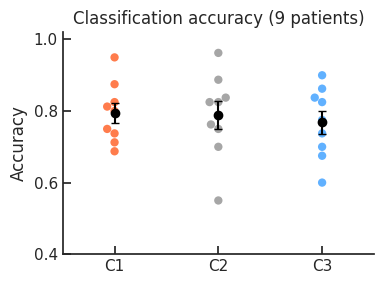

In [3]:
# classification = which side of the thresh a position lands on; correct when response and stim agree
classes = ['<thresh', '>thresh']
beh_trials_df['stim_class'] = np.where(beh_trials_df['true_stim'] > beh_trials_df['true_thresh'], '>thresh', '<thresh')
beh_trials_df['resp_class'] = np.where(beh_trials_df['true_resp'] > beh_trials_df['true_thresh'], '>thresh', '<thresh')
beh_trials_df['correct_class'] = beh_trials_df['stim_class'] == beh_trials_df['resp_class']

def swarm_mean_sem(ax, pt_values, x, y, order, colors):
    ''' one dot per patient (n=9 is too few for a density); black point = mean ± SEM across patients '''
    sns.swarmplot(data=pt_values, x=x, y=y, order=order, hue=x, palette=colors, legend=False, size=6, alpha=.7, ax=ax)
    pt_stats = pt_values.groupby(x)[y].agg(['mean', 'sem']).loc[order]
    ax.errorbar(range(len(order)), pt_stats['mean'], yerr=pt_stats['sem'], fmt='o', color='black', capsize=3, zorder=3)
    ax.set(xlim=(-.5, len(order) - .5))  # categorical padding, else the edge dots get clipped

# one accuracy per patient per context
pt_accs = beh_trials_df.groupby(['subj', 'context'])['correct_class'].mean().reset_index(name='acc')

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
swarm_mean_sem(ax, pt_accs, 'context', 'acc', contexts, cntxt_colors)
ax.set(title=f'Classification accuracy ({n_pts} patients)', xlabel='', ylabel='Accuracy', ylim=(.4, 1.02), yticks=[.4, .6, .8, 1])
plt.tight_layout(); plt.show()

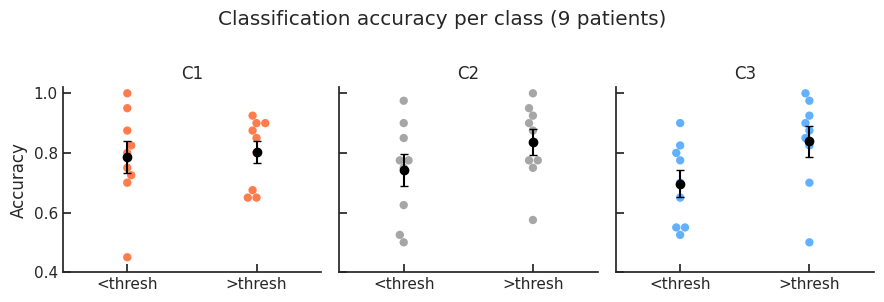

In [4]:
# accuracy split by which side of the thresh the stim was on: one value per patient per context per class
pt_class_accs = beh_trials_df.groupby(['subj', 'context', 'stim_class'])['correct_class'].mean().reset_index(name='acc')

fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharey=True); plt.suptitle(f'Classification accuracy per class ({n_pts} patients)', y=1)
for ax, cntxt in zip(axs, contexts):
    swarm_mean_sem(ax, pt_class_accs[pt_class_accs['context'] == cntxt], 'stim_class', 'acc', classes, dict.fromkeys(classes, cntxt_colors[cntxt]))
    ax.set(title=cntxt, xlabel='', ylabel='Accuracy' if cntxt == 'C1' else '', ylim=(.4, 1.02), yticks=[.4, .6, .8, 1])
plt.tight_layout(); plt.show()

### stim vs resp

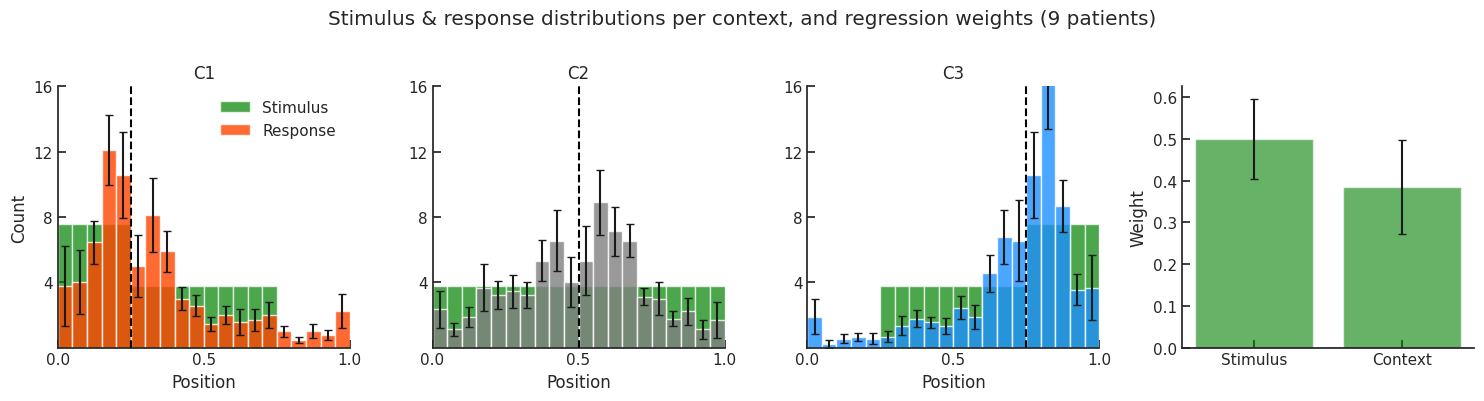

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4)); plt.suptitle(f'Stimulus & response distributions per context, and regression weights ({n_pts} patients)', y=1)
bins, bin_centers = np.linspace(-.4, .4, 21), np.linspace(-.38, .38, 20)

# --- cols 1-3: stimulus vs response distributions per context: histogram counts per patient -> mean (± SEM) across patients ---
for ax, cntxt, thresh in zip(axs[:3], contexts, threshs):
    ax.set(title=cntxt, xlabel='Position', ylabel='Count' if cntxt == 'C1' else '', xlim=(-.4, .4), ylim=(0, 16), xticks=np.linspace(-.4, .4, 3), xticklabels=np.linspace(0, 1, 3), yticks=np.linspace(4, 16, 4))
    cntxt_df = beh_trials_df[beh_trials_df['context'] == cntxt]
    stim_cts = np.array([np.histogram(pt_df['true_stim'], bins=bins)[0] for _, pt_df in cntxt_df.groupby('subj')])
    resp_cts = np.array([np.histogram(pt_df['true_resp'], bins=bins)[0] for _, pt_df in cntxt_df.groupby('subj')])
    ax.bar(bin_centers, stim_cts.mean(0), width=.04, color='green', alpha=.7, label='Stimulus')
    ax.bar(bin_centers, resp_cts.mean(0), width=.04, color=cntxt_colors[cntxt], alpha=.8, yerr=resp_cts.std(0, ddof=1) / np.sqrt(len(resp_cts)), capsize=3, label='Response')
    ax.axvline(thresh, color='black', linestyle='--')
axs[0].legend(frameon=False)

# --- col 4: regression weights, response ~ stimulus + context (thresh), one fit per patient ---
# same analysis as the network version in simulation1_training (per net there, per patient here)
pt_weights = []  # per patient: [beta_stim, beta_context]
for _, pt_df in beh_trials_df.groupby('subj'):
    design_mtx = np.column_stack([np.ones(len(pt_df)), pt_df['true_stim'], pt_df['true_thresh']])
    betas, *_ = np.linalg.lstsq(design_mtx, pt_df['true_resp'].values, rcond=None)
    pt_weights.append(betas[1:])  # drop intercept
pt_weights = np.array(pt_weights)  # (n_pts, 2)

axs[3].set(xticks=[0, 1], xticklabels=['Stimulus', 'Context'], ylabel='Weight')
axs[3].bar([0, 1], pt_weights.mean(0), yerr=pt_weights.std(0, ddof=1) / np.sqrt(n_pts), color='green', alpha=.6, capsize=3)
axs[3].axhline(0, color='black', linewidth=1)
plt.tight_layout(); plt.show()

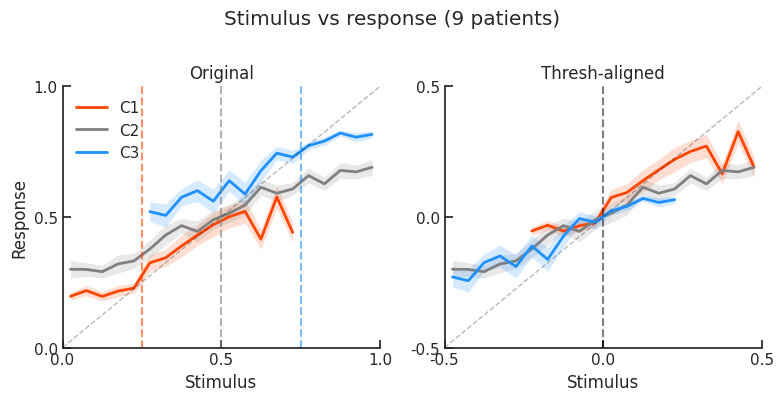

In [6]:
def plot_stim_vs_resp(ax, stim_col, resp_col):
    ''' mean response per unique stim per context, pooled over patients (± SEM across trials); dashed identity = response equals stim '''
    for cntxt in contexts:
        cntxt_df = beh_trials_df[beh_trials_df['context'] == cntxt]
        mean_resp, sem_resp = cntxt_df.groupby(stim_col)[resp_col].mean(), cntxt_df.groupby(stim_col)[resp_col].sem()
        ax.plot(mean_resp.index, mean_resp, '-', linewidth=2, color=cntxt_colors[cntxt], label=cntxt)
        ax.fill_between(mean_resp.index, mean_resp - sem_resp, mean_resp + sem_resp, color=cntxt_colors[cntxt], alpha=.18, linewidth=0)
    ax.plot([-.4, .4], [-.4, .4], 'k--', linewidth=1, alpha=.3)

fig, axs = plt.subplots(1, 2, figsize=(8, 4)); plt.suptitle(f'Stimulus vs response ({n_pts} patients)', y=1)
ticks = np.linspace(-.4, .4, 3)

# --- col 1: original positions, each context's thresh marked ---
axs[0].set(title='Original', xlabel='Stimulus', ylabel='Response', xlim=(-.4, .4), ylim=(-.4, .4), xticks=ticks, xticklabels=np.linspace(0, 1, 3), yticks=ticks, yticklabels=np.linspace(0, 1, 3))
plot_stim_vs_resp(axs[0], 'true_stim', 'true_resp')
for cntxt, thresh in zip(contexts, threshs): axs[0].axvline(thresh, color=cntxt_colors[cntxt], linestyle='--', linewidth=1.5, alpha=.6)
axs[0].legend(frameon=False)

# --- col 2: thresh-aligned positions, all threshs collapse onto 0 ---
axs[1].set(title='Thresh-aligned', xlabel='Stimulus', xlim=(-.4, .4), ylim=(-.4, .4), xticks=ticks, xticklabels=np.linspace(-.5, .5, 3), yticks=ticks, yticklabels=np.linspace(-.5, .5, 3))
plot_stim_vs_resp(axs[1], 'stim_thresh_aligned', 'resp_thresh_aligned')
axs[1].axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=.5)
plt.tight_layout(); plt.show()